# **Proses Analisis Data**
- **ID Tim Capstone Project:** CC26-PSU323
- **Tema Capstone:** Healty lives & well-being
- **Nama/Judul Proyek:** Sistem Analisis Gizi Seimbang Pada MBG

## Permasalahan Dikembangkan dalam Proyek

**Menentukan pertanyaan bisnis**
*Jawab pada Visualization & Explanatory Analysis*

1. Kategori makanan apa yang paling banyak terdapat pada dataset menu?
2. Kategori makanan mana yang memiliki rata-rata kalori tertinggi?
3. Apakah satu paket ompreng MBG sudah memenuhi komponen 4 Sehat 5 Sempurna?
4. Berapa total kandungan gizi dalam satu paket ompreng MBG?

## Proses Data Wrangling

## Import Library/Packages yang Digunakan

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

### Gathering Data

Tahap utama untuk tampilan memuat dataset dan menampilkan 5 baris pertama.

In [10]:
df_menu = pd.read_csv('/content/drive/MyDrive/MBG_scan/menu.csv')
df_menu.head()

,No,Nama,Lemak,Karbohidrat,Protein,Kalori,Kategori
0,1,nasi,0.28,27.90,2.66,129,Karbohidrat
1,2,nasi kuning,0.27,32.96,2.99,150,Karbohidrat
2,3,mie,2.06,25.01,4.51,137,Karbohidrat
3,4,kentang goreng,14.06,35.66,3.48,274,Karbohidrat
4,5,ayam crispy,17.99,7.60,17.61,263,Protein


In [11]:
df_targets= pd.read_csv('/content/drive/MyDrive/MBG_scan/target_akg.csv')
display(df_targets.head())

,tingkat_sekolah,target_kalori_siang,target_protein_siang,target_lemak_siang,target_karbohidrat_siang
0,TK,460,8.3,16.5,72.6
1,SD,610,16.0,20.4,91.3
2,SMP,740,22.3,24.8,107.3
3,SMA,790,23.2,25.6,115.5


Dataset **menu.csv**
- Mengumpulkannya dengan menyeleksi **50 nama menu** yang paling umum disajikan dalam Makan Bergizi Gratis (MBG).
- Riset akurasi gizi via **FatSecret**, yaitu: **Kalori** (kkal), **Protein** (gram), **Lemak** (gram), **Karbohidrat** (gram).

Dataset **target_akg.csv**
- Bersumber dari Peraturan **Kementerian Kesehatan RI (Permenkes No. 28 Tahun 2019)** tentang Angka Kecukupan Gizi yang dianjurkan untuk Masyarakat Indonesia.
- Aturan kemenkes menghitung kebutuhan untuk 1 hari (24 jam), Untuk project kita ambil **30%** untuk porsi makan siang anak sekolah.
- Dibagi per tingkat sekolah: **TK, SD, SMP, SMA.**

### Assessing Data

Tahap assessing data dilakukan untuk memahami kondisi awal dataset sebelum dilakukan proses pembersihan data (cleaning), untuk mengecek permasalahan data.
1. **Pemeriksaan tipe data:** Tipe data sesuai format.
2. **Pemeriksaan missing value:** Mengecek adanya data kosong.
3. **Pemeriksaan data duplikat:** Menditeksi kemungkinan adanya anomali.
4. **Ringkasan statistik dataset**: Melihat distribusi data (mean, median, min, max, dan kuartil).

#### df_menu

In [12]:
df_menu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No           50 non-null     int64  
 1   Nama         50 non-null     object 
 2   Lemak        50 non-null     float64
 3   Karbohidrat  50 non-null     float64
 4   Protein      50 non-null     float64
 5   Kalori       50 non-null     int64  
 6   Kategori     50 non-null     object 
dtypes: float64(3), int64(2), object(2)
memory usage: 2.9+ KB


In [13]:
df_menu.isnull().sum()

,0
No,0
Nama,0
Lemak,0
Karbohidrat,0
Protein,0
Kalori,0
Kategori,0


In [14]:
df_menu.duplicated().sum()

np.int64(0)

In [15]:
df_menu.describe()

,No,Lemak,Karbohidrat,Protein,Kalori
count,50.00000,50.000000,50.000000,50.000000,50.000000
mean,25.50000,3.829200,9.822600,4.857200,90.220000
std,14.57738,5.207161,9.064873,6.219937,79.586762
min,1.00000,0.000000,0.000000,0.000000,5.000000
25%,13.25000,0.255000,2.700000,0.935000,34.250000
50%,25.50000,2.145000,7.340000,2.230000,66.000000
75%,37.75000,4.200000,14.637500,5.822500,101.000000
max,50.00000,17.990000,35.660000,21.930000,287.000000


#### df_targets

In [16]:
df_targets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tingkat_sekolah           4 non-null      object 
 1   target_kalori_siang       4 non-null      int64  
 2   target_protein_siang      4 non-null      float64
 3   target_lemak_siang        4 non-null      float64
 4   target_karbohidrat_siang  4 non-null      float64
dtypes: float64(3), int64(1), object(1)
memory usage: 292.0+ bytes


In [17]:
df_targets.isnull().sum()

,0
tingkat_sekolah,0
target_kalori_siang,0
target_protein_siang,0
target_lemak_siang,0
target_karbohidrat_siang,0


In [18]:
df_targets.duplicated().sum()

np.int64(0)

In [19]:
df_targets.describe()

,target_kalori_siang,target_protein_siang,target_lemak_siang,target_karbohidrat_siang
count,4.000000,4.000000,4.00000,4.000000
mean,650.000000,17.450000,21.82500,96.675000
std,147.648231,6.889848,4.22246,18.936451
min,460.000000,8.300000,16.50000,72.600000
25%,572.500000,14.075000,19.42500,86.625000
50%,675.000000,19.150000,22.60000,99.300000
75%,752.500000,22.525000,25.00000,109.350000
max,790.000000,23.200000,25.60000,115.500000


### Cleaning Data

Tahap ini adalah memperbaiki permasalahan dataset,
pembersihan data agar data siap dianalisis.

In [20]:
# Menghapus data duplikat
df_menu = df_menu.drop_duplicates()

In [21]:
df_menu = df_menu.dropna()

In [22]:
# Merapikan nama kolom
df_menu.columns = df_menu.columns.str.strip()
df_targets.columns = df_targets.columns.str.strip()

In [23]:
# Standarisasi kategori
df_menu['Kategori'] = df_menu['Kategori'].str.strip()
df_menu['Kategori'] = df_menu['Kategori'].str.title()

In [24]:
# Standarisasi nama
df_menu['Nama'] = df_menu['Nama'].str.strip()
df_menu['Nama'] = df_menu['Nama'].str.lower()

In [25]:
print("Cek Missing Values:\n", df_menu.isna().sum())
print("\nCek Duplikat:", df_menu.duplicated().sum())

Cek Missing Values:
 No             0
Nama           0
Lemak          0
Karbohidrat    0
Protein        0
Kalori         0
Kategori       0
dtype: int64

Cek Duplikat: 0


Membuat label target
- Tahap ini dilakukan untuk mengubah data kategori makanan berbentuk teks menjadi numerik agar dapat diproses lebih mudah.

In [26]:
label_map = {
    'Karbohidrat': 0,
    'Protein': 1,
    'Sayur': 2,
    'Buah': 3,
    'Minuman': 4,
    'Pelengkap': 5
}

df_menu['label_target'] = df_menu['Kategori'].map(label_map)

print(df_menu.head())

   No            Nama  Lemak  Karbohidrat  Protein  Kalori     Kategori  \
0   1            nasi   0.28        27.90     2.66     129  Karbohidrat   
1   2     nasi kuning   0.27        32.96     2.99     150  Karbohidrat   
2   3             mie   2.06        25.01     4.51     137  Karbohidrat   
3   4  kentang goreng  14.06        35.66     3.48     274  Karbohidrat   
4   5     ayam crispy  17.99         7.60    17.61     263      Protein   

   label_target  
0             0  
1             0  
2             0  
3             0  
4             1  


In [27]:
# Contoh analisis per ompreng
menu_ompreng = [
    'nasi',
    'ayam goreng',
    'capcay',
    'pisang',
    'susu uht'
]

In [28]:
# Mencocokan label dengan contoh analisis
df_ompreng = df_menu[
    df_menu['Nama'].isin(menu_ompreng)
]

print(df_ompreng)

    No         Nama  Lemak  Karbohidrat  Protein  Kalori     Kategori  \
0    1         nasi   0.28        27.90     2.66     129  Karbohidrat   
5    6  ayam goreng  14.55        10.76    21.93     260      Protein   
22  23       capcay   2.59         9.67     1.58      67        Sayur   
37  38     susu uht   2.58         6.07     4.24      64      Minuman   
48  49       pisang   0.33        22.84     1.09      89         Buah   

    label_target  
0              0  
5              1  
22             2  
37             4  
48             3  


Menghitung total kandungan gizi satu ompreng

In [29]:
total_kalori = df_ompreng['Kalori'].sum()
print("Total Kalori :", total_kalori)

Total Kalori : 609


In [30]:
total_protein = df_ompreng['Protein'].sum()
print("Total Protein :", total_protein)

Total Protein : 31.500000000000004


In [31]:
total_lemak = df_ompreng['Lemak'].sum()
print("Total Lemak :", total_lemak)

Total Lemak : 20.33


In [32]:
total_karbo = df_ompreng['Karbohidrat'].sum()
print("Total Karbohidrat :", total_karbo)

Total Karbohidrat : 77.24


## EDA (Exploratory Data Analysis)

Memahami pola , karakteristik, informasi sebelum melakukan visualisasi yang menjawab pertanyaan bisnis berdasarkan hasil analisis.

In [33]:
print(df_menu['Kategori'].value_counts())

Kategori
Protein        17
Sayur          12
Buah           12
Karbohidrat     4
Pelengkap       3
Minuman         2
Name: count, dtype: int64


**Insight:**
- Kategori protein memiliki jumlah menu paling banyak dibanding kategori lain.

In [34]:
print(df_menu.groupby('Kategori')['Kalori'].mean())

Kategori
Buah            50.916667
Karbohidrat    172.500000
Minuman         83.000000
Pelengkap       25.000000
Protein        136.000000
Sayur           54.750000
Name: Kalori, dtype: float64


**Insight:**
- Kategori karbohidrat dan protein memiliki rata-rata kalori lebih tinggi.

In [35]:
print(
    df_menu.sort_values(
        by='Kalori',
        ascending=False
    ).head()
)

    No            Nama  Lemak  Karbohidrat  Protein  Kalori     Kategori  \
10  11    udang goreng  14.64        27.57    10.58     287      Protein   
3    4  kentang goreng  14.06        35.66     3.48     274  Karbohidrat   
13  14          pentol  15.88        17.23    13.74     269      Protein   
4    5     ayam crispy  17.99         7.60    17.61     263      Protein   
7    8   ayam kentucky  17.99         7.60    17.61     263      Protein   

    label_target  
10             1  
3              0  
13             1  
4              1  
7              1  


**Insight:**
- Menu gorengan memiliki kandungan kalori yang tinggi.

In [36]:
kategori_wajib = [
    'Karbohidrat',
    'Protein',
    'Sayur',
    'Buah',
    'Minuman'
]

kategori_ompreng = df_ompreng['Kategori'].unique()

for kategori in kategori_wajib:
    if kategori in kategori_ompreng:
        print(kategori, "Memenuhi")
    else:
        print(kategori, "Belum Memenuhi")

Karbohidrat Memenuhi
Protein Memenuhi
Sayur Memenuhi
Buah Memenuhi
Minuman Memenuhi


**Insight:**
- Ompreng MBG sudah memenuhi komponen 4 Sehat 5 Sempurna.

## Visualization & Explanatory Analysis

### **Pertanyaan 1**: Kategori makanan apa yang paling banyak terdapat pada dataset menu?

In [37]:
kategori_terbanyak = df_menu['Kategori'].value_counts().idxmax()
jumlah_terbanyak = df_menu['Kategori'].value_counts().max()
print(f"Kategori terbanyak: {kategori_terbanyak} ({jumlah_terbanyak} item)")

Kategori terbanyak: Protein (17 item)


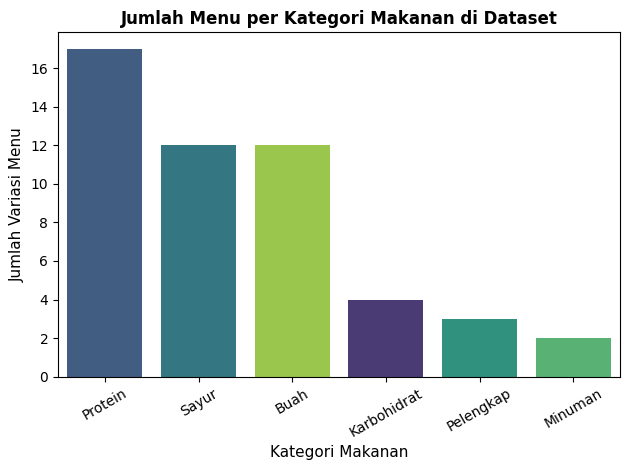

In [38]:
# Membuat grafik batang jumlah menu per kategori
sns.countplot(
    data=df_menu,
    x='Kategori',
    order=df_menu['Kategori'].value_counts().index,
    hue='Kategori',
    palette='viridis',
    legend=False
)

plt.title('Jumlah Menu per Kategori Makanan di Dataset', fontsize=12, fontweight='bold')
plt.xlabel('Kategori Makanan', fontsize=11)
plt.ylabel('Jumlah Variasi Menu', fontsize=11)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Jawaban**:
- Kategori makanan yang paling dominan dan memiliki variasi menu paling banyak di dataset adalah **Protein.**

### **Pertanyaan 2**: Kategori makanan mana yang memiliki rata-rata kalori tertinggi?


In [39]:
kalori_tertinggi = df_menu.groupby('Kategori')['Kalori'].mean().idxmax()
nilai_kalori = df_menu.groupby('Kategori')['Kalori'].mean().max()
print(f"Rata-rata kalori tertinggi: {kalori_tertinggi} ({nilai_kalori:.2f} kkal)")

Rata-rata kalori tertinggi: Karbohidrat (172.50 kkal)


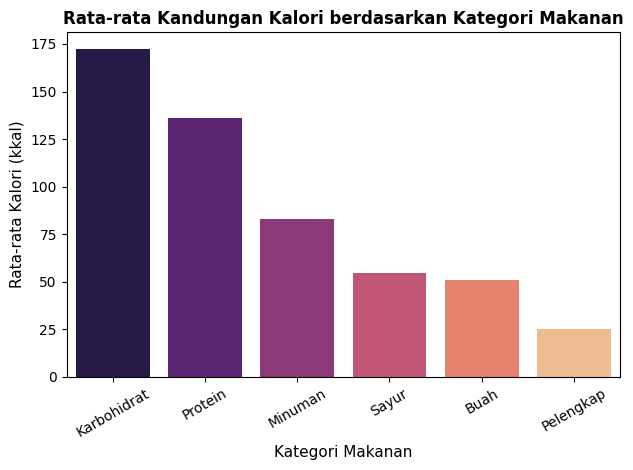

In [40]:
# Menghitung rata-rata kalori lalu diurutkan dari yang tertinggi
df_grup_kalori = df_menu.groupby('Kategori')['Kalori'].mean().reset_index().sort_values(by='Kalori', ascending=False)

# Membuat grafik batang rata-rata kalori
sns.barplot(
    data=df_grup_kalori,
    x='Kategori',
    y='Kalori',
    hue='Kategori',
    palette='magma',
    legend=False
)

plt.title('Rata-rata Kandungan Kalori berdasarkan Kategori Makanan', fontsize=12, fontweight='bold')
plt.xlabel('Kategori Makanan', fontsize=11)
plt.ylabel('Rata-rata Kalori (kkal)', fontsize=11)
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**Jawaban**:
- Kategori makanan menyumbang energi rata-rata kalori tertinggi per porsinya adalah **karbohidrat.**

### **Pertanyaan 3**: Apakah satu paket ompreng MBG sudah memenuhi komponen 4 Sehat 5 Sempurna?

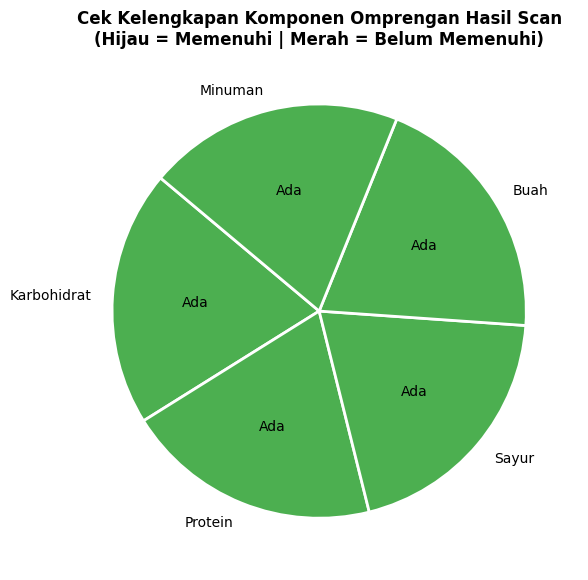

In [41]:
# Menentukan komponen wajib gizi seimbang
kategori_wajib = ['Karbohidrat', 'Protein', 'Sayur', 'Buah', 'Minuman']
kategori_ompreng = df_ompreng['Kategori'].unique()

# Mengecek ketersediaan komponen di isi omprengan saat ini
status_komponen = [1 if kat in kategori_ompreng else 0 for kat in kategori_wajib]

# Membuat grafik lingkaran kelengkapan (Pie Chart)
plt.figure(figsize=(6, 6))
colors = ['#4CAF50' if val == 1 else '#FF5722' for val in status_komponen]

plt.pie(
    [1]*len(kategori_wajib),
    labels=kategori_wajib,
    colors=colors,
    autopct=lambda p: 'Ada' if status_komponen[int(p/20)] == 1 else 'Tidak Ada',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

plt.title('Cek Kelengkapan Komponen Omprengan Hasil Scan\n(Hijau = Memenuhi | Merah = Belum Memenuhi)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Jawaban**:
- Berdasarkan simulasi satu ompreng yang diuji sudah memenuhi seluruh komponen gizi seimbang karena status ada (hijau).

### **Pertanyaan 4**: Berapa total kandungan gizi dalam satu paket ompreng MBG?

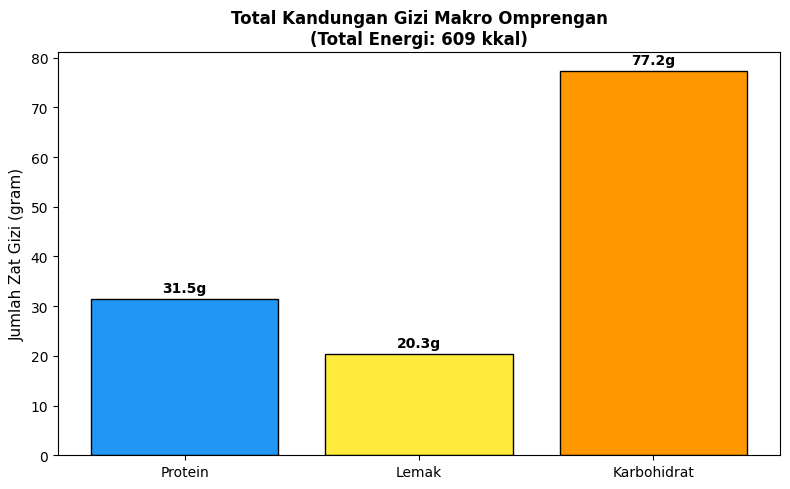

In [42]:
# Membuat rangkuman total gizi makro dari df_ompreng kamu
gizi_total = {
    'Zat Gizi': ['Protein', 'Lemak', 'Karbohidrat'],
    'Total (gram)': [df_ompreng['Protein'].sum(), df_ompreng['Lemak'].sum(), df_ompreng['Karbohidrat'].sum()]
}
df_total_gizi = pd.DataFrame(gizi_total)

#  Membuat grafik batang total kandungan gizi
plt.figure(figsize=(8, 5))
bars = plt.bar(
    df_total_gizi['Zat Gizi'],
    df_total_gizi['Total (gram)'],
    color=['#2196F3', '#FFEB3B', '#FF9800'],
    edgecolor='black'
)

# Menampilkan total energi kalori di judul grafik
total_kalori_piring = round(df_ompreng['Kalori'].sum(), 1)
plt.title(f'Total Kandungan Gizi Makro Omprengan\n(Total Energi: {total_kalori_piring} kkal)', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Zat Gizi (gram)', fontsize=11)

# Menambahkan label angka pas di atas batang grafik
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.8, f"{round(yval, 1)}g", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

**Jawaban**:
- Satu porsi omprengan makan siang yang di-scan menghasilkan total energi sebesar **609 kkal**. Dengan rincian zat gizi makronutrisi: **Protein: 31.5g**, **Lemak: 20.3g**, dan **Karbohidrat: 77.2g**.

## Kesimpulan

Berdasarkan hasil analisis data, kategori protein sebagai menu yang paling banyak pada dataset. Selain itu, kandungan kalori terbanyak berasal dari makanan gorengan.

Pengecekan satu ompreng MBG yang sudah memenuhi komponen 4 Sehat 5 Sempurna yaitu adanya karbohidrat, protein, sayur, buah, dan susu. Perhitungan total kandungan gizi satu ompreng digunakan untuk membantu kelengkapan kebutuhan energi dan gizi makan siang.

In [43]:
df_menu.to_csv("data_gizi.csv", index=False)

## Marchine Learning K-Nearest Neighbors (KNN)

In [62]:
df_menu

,No,Nama,Lemak,Karbohidrat,Protein,Kalori,Kategori,label_target
0,1,nasi,0.28,27.90,2.66,129,Karbohidrat,0
1,2,nasi kuning,0.27,32.96,2.99,150,Karbohidrat,0
2,3,mie,2.06,25.01,4.51,137,Karbohidrat,0
3,4,kentang goreng,14.06,35.66,3.48,274,Karbohidrat,0
4,5,ayam crispy,17.99,7.60,17.61,263,Protein,1
5,6,ayam goreng,14.55,10.76,21.93,260,Protein,1
6,7,ayam kecap,11.96,9.41,18.82,233,Protein,1
7,8,ayam kentucky,17.99,7.60,17.61,263,Protein,1
8,9,ayam suwir,2.07,0.00,21.86,122,Protein,1
9,10,sate,2.22,0.73,2.93,34,Protein,1


In [47]:
print("Cek jumlah menu per kategori")
print(df_menu['Kategori'].value_counts())
print("-" * 50)

Cek jumlah menu per kategori
Kategori
Protein        17
Sayur          12
Buah           12
Karbohidrat     4
Pelengkap       3
Minuman         2
Name: count, dtype: int64
--------------------------------------------------


In [50]:
from sklearn.preprocessing import LabelEncoder

# Duplikat data asli Anda agar analisis grafik di atas tidak ikut berubah
df_ml = df_menu.copy()

# Buang kolom 'No'
if 'No' in df_ml.columns:
    df_ml = df_ml.drop(['No'], axis=1)

# Ubah teks Kategori menjadi kode angka (Label Encoding)
le = LabelEncoder()
if 'Kategori' in df_ml.columns:
    df_ml['Kategori'] = le.fit_transform(df_ml['Kategori'])
    print("Mapping Angka Kategori")
    print(dict(enumerate(le.classes_)))
    print("-" * 50)

# Pisahkan Fitur Gizi (X) dan Target Kategori (y)
X = df_ml.drop(['Nama', 'Kategori'], axis=1, errors='ignore')
y = df_ml['Kategori']

print("[SUKSES] Bagian 1: Fitur (X) dan Target (y) telah siap!")

Mapping Angka Kategori
{0: 'Buah', 1: 'Karbohidrat', 2: 'Minuman', 3: 'Pelengkap', 4: 'Protein', 5: 'Sayur'}
--------------------------------------------------
[SUKSES] Bagian 1: Fitur (X) dan Target (y) telah siap!


In [73]:
from sklearn.preprocessing import LabelEncoder

# Duplikat data asli agar analisis grafik sebelumnya tidak berubah
df_ml = df_menu.copy()

# Buang kolom 'No' jika ada
if 'No' in df_ml.columns:
    df_ml = df_ml.drop(['No'], axis=1)

# Memastikan nama kolom bersih dari spasi dan seragam
df_ml.columns = df_ml.columns.str.strip()


# Membuat wadah penyimpanan (Dictionary)
label_encoders = {}

if 'Kategori' in df_ml.columns:
    le = LabelEncoder()
    df_ml['Kategori'] = le.fit_transform(df_ml['Kategori'].astype(str))

    # Simpan objek encoder ke dalam wadah dictionary dengan kunci 'Kategori'
    label_encoders['Kategori'] = le

    print("[INFO] Proses Label Encoding untuk kolom 'Kategori' berhasil.")
    print("-" * 60)
    print("Mapping Angka Kategori")
    print(dict(enumerate(le.classes_)))
else:
    print("[PERINGATAN] Kolom 'Kategori' tidak ditemukan pada dataset.")

# Pemisahan Fitur Gizi (X) dan Target Kategori (y)
X = df_ml.drop(['Nama', 'Kategori'], axis=1, errors='ignore')
y = df_ml['Kategori']

print("Status: Pemisahan variabel Fitur (X) dan Target (y) selesai.")

[INFO] Proses Label Encoding untuk kolom 'Kategori' berhasil.
------------------------------------------------------------
Mapping Angka Kategori
{0: 'Buah', 1: 'Karbohidrat', 2: 'Minuman', 3: 'Pelengkap', 4: 'Protein', 5: 'Sayur'}
Status: Pemisahan variabel Fitur (X) dan Target (y) selesai.


**LabelEncoder{}**: Wadah ini nantinya berfungsi sebagai tempat menyimpan "kamus terjemahan" belum ada isi.

**label_encoders['Kategori'] = le** adalah memasukkan Kamus Terjemahan Kategori (yang isinya catatan: Buah = 0, Protein = 4) ke dalam kotak wadah tersebut.

Memisahkan $X$ dan $y$:
- $X$ (Fitur/Soal): Diambil dari angka-angka kandungan gizi (Lemak, Karbohidrat, Protein, Kalori). Kolom teks seperti 'Nama' dan 'Kategori' dibuang dari $X$.
- $y$ (Target/Kunci Jawaban): Hanya berisi kolom 'Kategori' yang sudah diubah jadi angka.

In [74]:
from sklearn.model_selection import train_test_split

# Membagi data menjadi 80% Data Latih dan 20% Data Uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("PROPORSI DATA UJIAN")
print(f"Jumlah Menu untuk Komputer Belajar (Train Set): {X_train.shape[0]} menu")
print(f"Jumlah Menu untuk Ujian Rahasia (Test Set)  : {X_test.shape[0]} menu")

PROPORSI DATA UJIAN
Jumlah Menu untuk Komputer Belajar (Train Set): 40 menu
Jumlah Menu untuk Ujian Rahasia (Test Set)  : 10 menu


**fungsi train_test_split** dengan porsi 80% : 20%.

- **Data Latih (Train Set - 40 Menu):** 80% data yang diberikan kepada komputer lengkap beserta kunci jawabannya. Komputer menggunakannya untuk belajar menghafal pola gizi dari masing-masing kategori makanan.

- **Data Uji (Test Set - 10 Menu):** 20% data sisa yang disimpan rapat-rapat sebagai soal ujian rahasia. Komputer tidak boleh melihat kunci jawabannya saat menguji kemampuannya.

In [75]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# Panggil dan latih model KNN
model_knn = KNeighborsClassifier(n_neighbors=1)
model_knn.fit(X_train, y_train)

# Prediksi data ujian
y_pred = model_knn.predict(X_test)

# Tampilkan hasil akurasi dan rapor detail
print("--- Hasil Ujian Komputer (Model KNN) ---")
print(f"Akurasi Total: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("")
print("Rapor Detail per Kategori:")

kategori_ada = [le.classes_[i] for i in np.unique(y_test)]
print(classification_report(y_test, y_pred, labels=np.unique(y_test), target_names=kategori_ada))

--- Hasil Ujian Komputer (Model KNN) ---
Akurasi Total: 70.00%

Rapor Detail per Kategori:
              precision    recall  f1-score   support

        Buah       0.67      0.67      0.67         3
     Protein       0.75      1.00      0.86         3
       Sayur       0.67      0.50      0.57         4

    accuracy                           0.70        10
   macro avg       0.69      0.72      0.70        10
weighted avg       0.69      0.70      0.69        10



**Akurasi Total:** 70.00% (Artinya 7 dari 10 menu berhasil ditebak dengan benar).

 **Detail Tebakannya:**
1. Bagian **Lauk/Protein** (Nilai Sempurna): Semua soal tentang lauk pauk berhasil ditebak 100% benar karena angka protein pada daging/telur sangat khas dan mudah dikenali.
2. Bagian **Sayur & Buah** (Masih Sering Tertukar): Komputer kadang masih bingung membedakan sayur dan buah. Kenapa? angka gizi sayur dan buah itu mirip sekali (sama-sama rendah kalori dan rendah lemak).